In [ ]:
# Project 1: Advanced EDA & Feature Engineering

#Objective:
#Transform raw, chaotic data into a mathematically clean dataset ready for machine learning.

#Dataset: Dataset for Data Analytics.xlsx

#Performed by:
#Ritika Rani

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.impute import KNNImputer

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics.xlsx


In [ ]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(1200, 14)

Column Names:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.describe(include="all")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,NaN,C46651,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


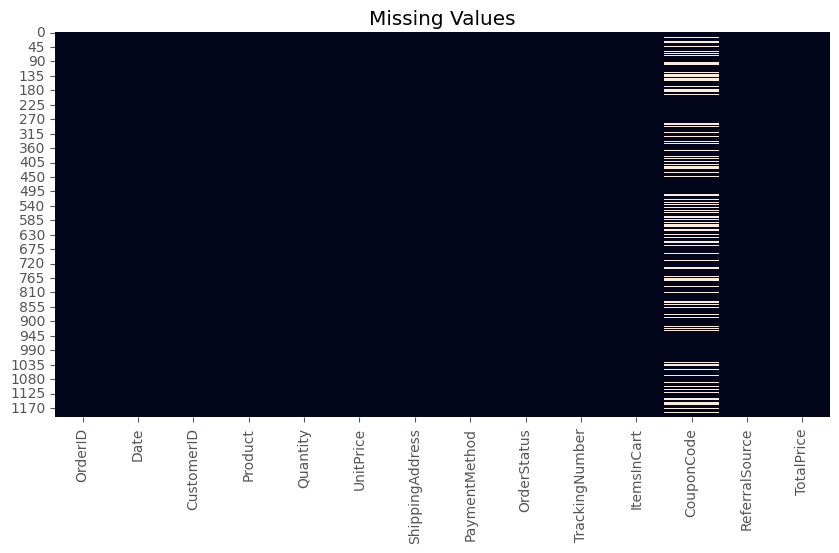

In [ ]:
missing = df.isnull().sum()

missing

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
outlier_columns = ["Quantity","UnitPrice","TotalPrice"]

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col)

    print("Number of Outliers:",len(outliers))

    print("----------------------")

Quantity
Number of Outliers: 0
----------------------
UnitPrice
Number of Outliers: 0
----------------------
TotalPrice
Number of Outliers: 8
----------------------


In [ ]:
for col in outlier_columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    df = df[(df[col]>=lower) & (df[col]<=upper)]

print(df.shape)

(1192, 14)


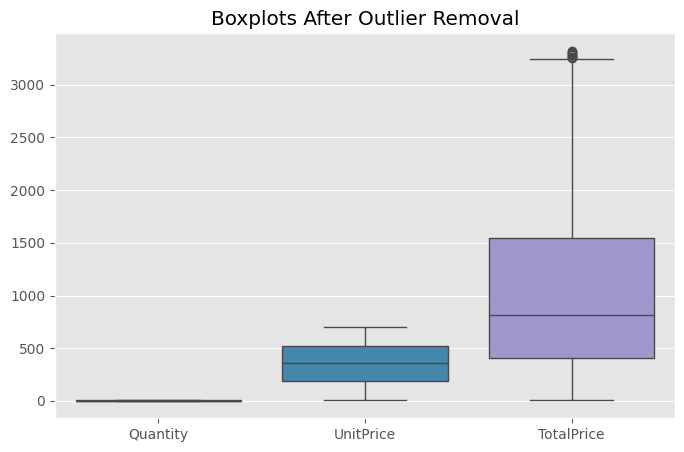

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[outlier_columns])

plt.title("Boxplots After Outlier Removal")

plt.show()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["PricePerItem"] = df["TotalPrice"] / df["Quantity"]

df["ExtraCartItems"] = df["ItemsInCart"] - df["Quantity"]

df["OrderMonth"] = df["Date"].dt.month

df["OrderDay"] = df["Date"].dt.day_name()

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,PricePerItem,ExtraCartItems,OrderMonth,OrderDay
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,2,1,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,1,8,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,3,2,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,4,10,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,4,5,Thursday


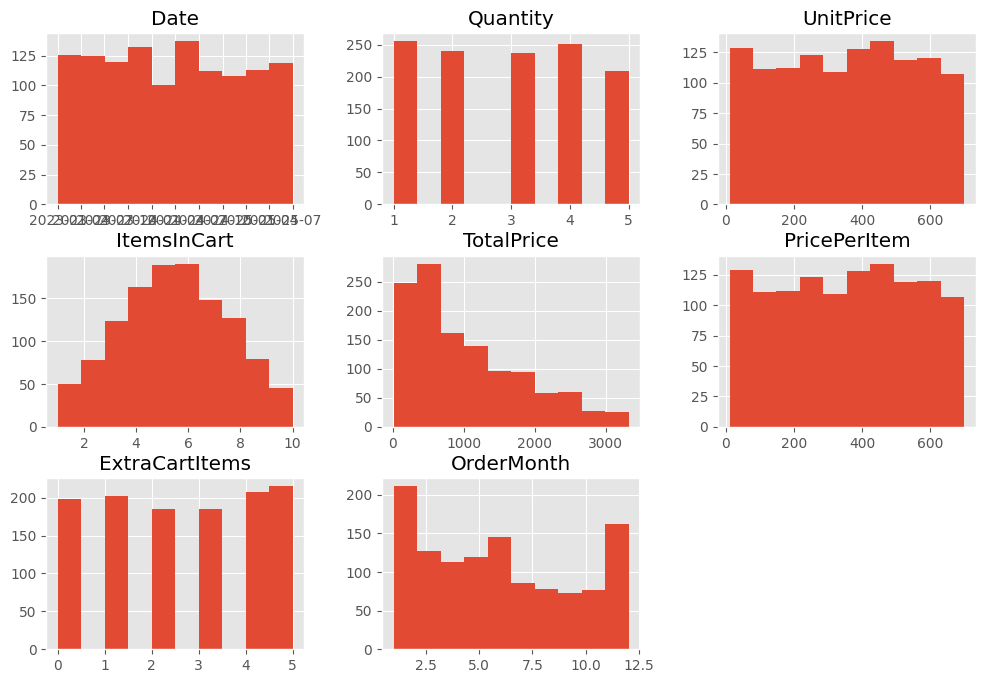

In [ ]:
df.hist(figsize=(12,8))

plt.show()

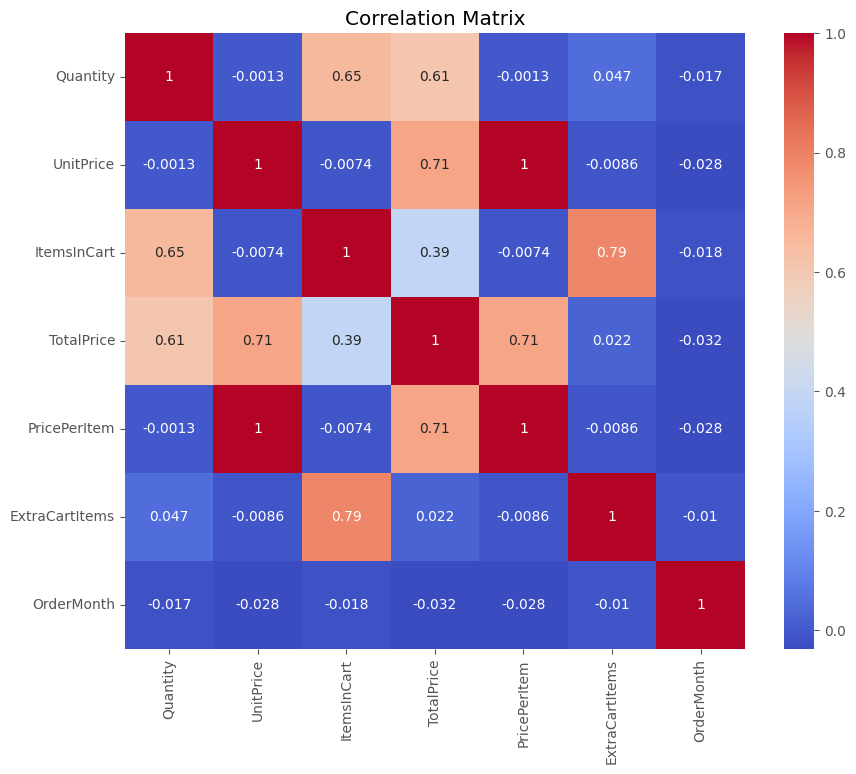

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

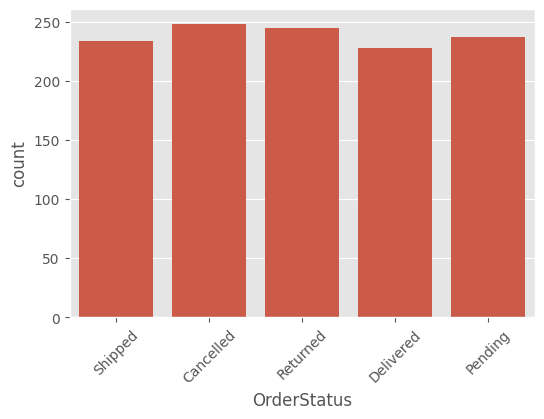

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="OrderStatus",data=df)

plt.xticks(rotation=45)

plt.show()

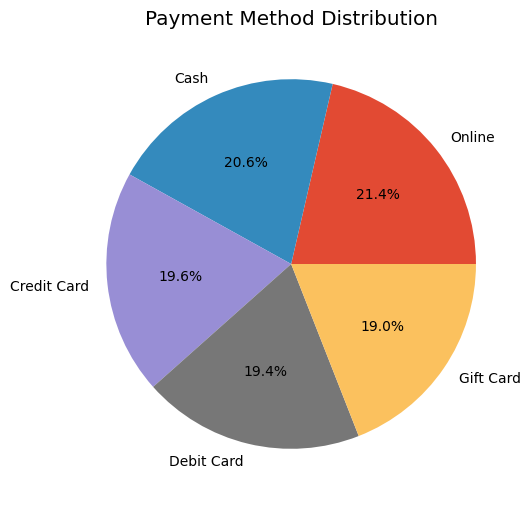

In [ ]:
plt.figure(figsize=(6,6))

df["PaymentMethod"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Payment Method Distribution")

plt.show()

In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,PricePerItem,ExtraCartItems,OrderMonth,OrderDay
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,2,1,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,1,8,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,3,2,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,4,10,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,4,5,Thursday


In [ ]:
df.to_excel("Cleaned_Dataset.xlsx",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
from google.colab import files

files.download("Cleaned_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Conclusion

#This project transformed a raw dataset into a machine-learning-ready dataset by:

#Performing exploratory data analysis (EDA)

#Identifying and handling missing values using statistical imputation

#Detecting and removing outliers using the IQR method

#Engineering four new predictive features:
#- PricePerItem
#- ExtraCartItems
#- OrderMonth
#- OrderDay

#Visualizing distributions and relationships between variables

#The resulting cleaned dataset is now suitable for machine learning algorithms.